# Analyse exploratoire (EDA) — Credit Score Classification

Ce notebook explore le jeu de données nettoyé `data/train_cleaned.csv`
(100 000 lignes correspondant à des relevés mensuels pour un ensemble de clients
bancaires) afin de comprendre la structure des données avant modélisation.

**Cible :** `Credit_Score`, variable catégorielle à 3 classes : `Good`, `Standard`, `Poor`.

**Plan :**
1. Chargement et statistiques descriptives complètes
2. Analyse de la variable cible
3. Analyse univariée des variables numériques
4. Analyse bivariée : variables numériques vs `Credit_Score`
5. Analyse des variables catégorielles vs `Credit_Score`
6. Matrice de corrélation
7. Élasticité des revenus : variabilité intra-client
8. Synthèse des insights clés pour la modélisation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## Style graphique et palette

On définit une palette cohérente, utilisée dans tout le notebook :

- **Cible `Credit_Score`** (palette de statut, fixe) : `Good` = vert, `Standard` = orange,
  `Poor` = rouge — jamais réutilisées pour autre chose, toujours dans cet ordre.
- **Variables numériques (histogrammes)** : une seule teinte bleue (encodage séquentiel
  à une seule série).
- **Corrélations** : palette divergente bleu ↔ rouge avec un point neutre gris à 0,
  car une corrélation a un signe (polarité), pas seulement une magnitude.
- Grilles fines et discrètes, axes du haut/droite masqués, police sans-serif.


In [2]:
# Palette de statut pour la cible (fixe, jamais recyclée pour autre chose)
STATUS_COLORS = {
    'Good': '#0ca30c',
    'Standard': '#fab219',
    'Poor': '#d03b3b',
}
CREDIT_SCORE_ORDER = ['Good', 'Standard', 'Poor']

SEQUENTIAL_BLUE = '#2a78d6'
PRIMARY_INK = '#0b0b0b'
SECONDARY_INK = '#52514e'
MUTED_INK = '#898781'
GRID_COLOR = '#e1e0d9'
SURFACE = '#fcfcfb'

# Palette divergente bleu (négatif) -> gris neutre (0) -> rouge (positif)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'diverging_blue_red', ['#2a78d6', '#f0efec', '#e34948']
)

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID_COLOR,
    'axes.grid': True,
    'grid.color': GRID_COLOR,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': PRIMARY_INK,
    'axes.labelcolor': SECONDARY_INK,
    'xtick.color': MUTED_INK,
    'ytick.color': MUTED_INK,
    'text.color': PRIMARY_INK,
    'font.family': 'sans-serif',
    'font.size': 10.5,
})
sns.set_style('whitegrid', {'axes.facecolor': SURFACE, 'grid.color': GRID_COLOR})


## 1. Chargement et statistiques descriptives complètes

On charge le dataset nettoyé et on établit un diagnostic descriptif complet :
dimensions, types, valeurs manquantes résiduelles, et statistiques descriptives
pour les variables numériques et catégorielles.


In [3]:
df = pd.read_csv('../data/train_cleaned.csv', low_memory=False)
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Nombre de clients uniques (Customer_ID) : {df['Customer_ID'].nunique()}")


Dimensions : 100000 lignes x 29 colonnes
Nombre de clients uniques (Customer_ID) : 12500


In [4]:
df.dtypes


ID                               str
Customer_ID                      str
Month                            str
Name                             str
Age                          float64
SSN                              str
Occupation                       str
Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts            float64
Num_Credit_Card              float64
Interest_Rate                float64
Num_of_Loan                  float64
Type_of_Loan                     str
Delay_from_due_date            int64
Num_of_Delayed_Payment       float64
Changed_Credit_Limit         float64
Num_Credit_Inquiries         float64
Credit_Mix                       str
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Credit_History_Age               str
Payment_of_Min_Amount            str
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Payment_Behaviour                str
Monthly_Balance              float64
C

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Valeurs manquantes résiduelles :")
missing


Valeurs manquantes résiduelles :


Name                  9985
Credit_History_Age    9030
SSN                   5572
dtype: int64

In [6]:
# Statistiques descriptives — variables numériques
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,100000.0,33.314600,10.773909,14.000000,24.000000,33.000000,42.000000,100.000000
Annual_Income,100000.0,50518.846732,38335.621871,7005.930000,19344.270000,37002.580000,71689.680000,277803.000000
Monthly_Inhand_Salary,100000.0,4198.771619,3187.494355,303.645417,1626.761667,3096.378333,5961.745000,15204.633333
Num_Bank_Accounts,100000.0,5.368840,2.593273,0.000000,3.000000,5.000000,7.000000,11.000000
Num_Credit_Card,100000.0,5.533910,2.067712,0.000000,4.000000,5.000000,7.000000,15.000000
Interest_Rate,100000.0,14.532080,8.741330,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,100000.0,3.532880,2.446356,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_of_Delayed_Payment,100000.0,29.693800,218.027042,-3.000000,9.000000,14.000000,18.000000,4397.000000
Changed_Credit_Limit,100000.0,10.389113,6.783421,-6.490000,5.340000,9.400000,14.850000,36.970000


In [7]:
# Statistiques descriptives — variables catégorielles
df.describe(include='object').T


C:\Users\hp\AppData\Local\Temp\ipykernel_15740\988285099.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
SSN,94428,12500,004-07-5839,8
Occupation,100000,15,Lawyer,7096
Type_of_Loan,100000,6261,No Loan,11408
Credit_Mix,100000,3,Standard,45848
Credit_History_Age,90970,404,15 Years and 11 Months,446
Payment_of_Min_Amount,100000,2,Yes,59432


## 2. Analyse de la variable cible : `Credit_Score`

La cible est déséquilibrée entre les trois classes. On visualise sa distribution
en effectifs et en pourcentages via un diagramme en barres et un camembert — les
deux graphiques portant le même message (répartition d'un tout en 3 parts), le
camembert reste lisible ici car il n'y a que 3 catégories.


In [8]:
target_counts = df['Credit_Score'].value_counts().reindex(CREDIT_SCORE_ORDER)
target_pct = (target_counts / target_counts.sum() * 100).round(2)

resume_cible = pd.DataFrame({'Effectif': target_counts, 'Pourcentage (%)': target_pct})
resume_cible


,Effectif,Pourcentage (%)
Credit_Score,,
Good,17828,17.83
Standard,53174,53.17
Poor,28998,29.00


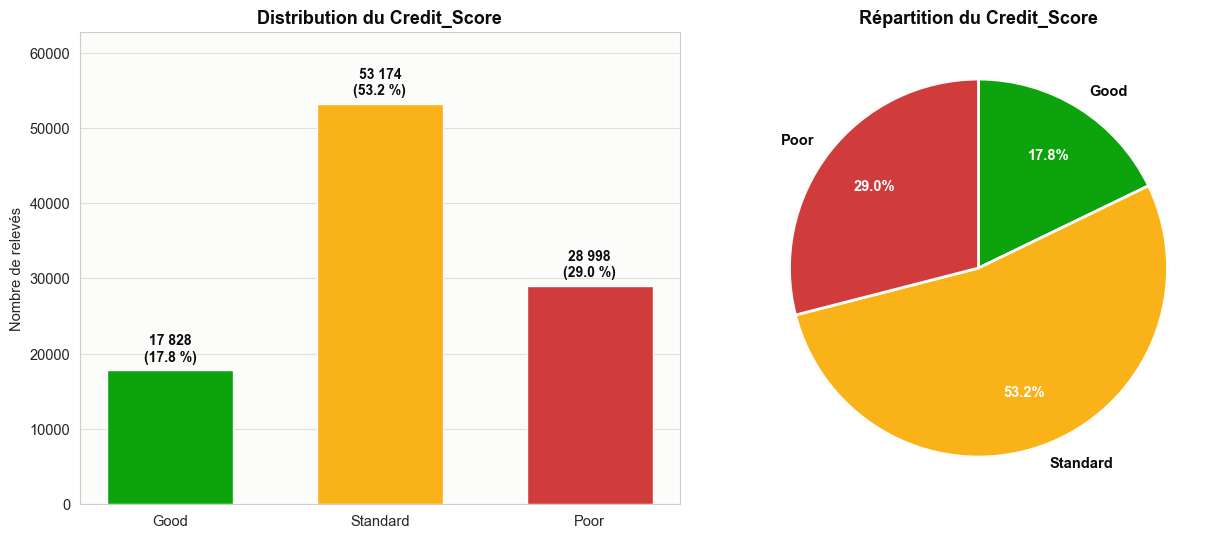

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Barplot avec pourcentages ---
ax = axes[0]
bars = ax.bar(
    CREDIT_SCORE_ORDER,
    target_counts.values,
    color=[STATUS_COLORS[c] for c in CREDIT_SCORE_ORDER],
    width=0.6,
)
for bar, pct, count in zip(bars, target_pct.values, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + target_counts.max() * 0.015,
        f"{count:,}".replace(',', ' ') + f"\n({pct:.1f} %)",
        ha='center', va='bottom', fontsize=10, color=PRIMARY_INK, fontweight='bold',
    )
ax.set_ylim(0, target_counts.max() * 1.18)
ax.set_ylabel("Nombre de relevés")
ax.set_title("Distribution du Credit_Score")
ax.grid(axis='x', visible=False)

# --- Camembert ---
ax = axes[1]
wedges, _, autotexts = ax.pie(
    target_counts.values,
    labels=CREDIT_SCORE_ORDER,
    colors=[STATUS_COLORS[c] for c in CREDIT_SCORE_ORDER],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.7,
    wedgeprops={'edgecolor': SURFACE, 'linewidth': 2},
    textprops={'color': PRIMARY_INK, 'fontweight': 'bold'},
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
ax.set_title("Répartition du Credit_Score")

plt.tight_layout()
plt.show()


**Lecture :** la classe `Standard` domine largement, `Poor` est la deuxième classe
la plus fréquente et `Good` est minoritaire. Ce déséquilibre devra être pris en
compte lors de la modélisation (pondération des classes, métriques adaptées comme
le F1 macro plutôt que l'accuracy brute, etc.).


## 3. Analyse univariée des variables numériques

Histogrammes (avec estimation de densité) des principales variables numériques,
tous tracés dans la même teinte bleue puisqu'il s'agit à chaque fois d'une série
unique — seule la forme de la distribution porte l'information.


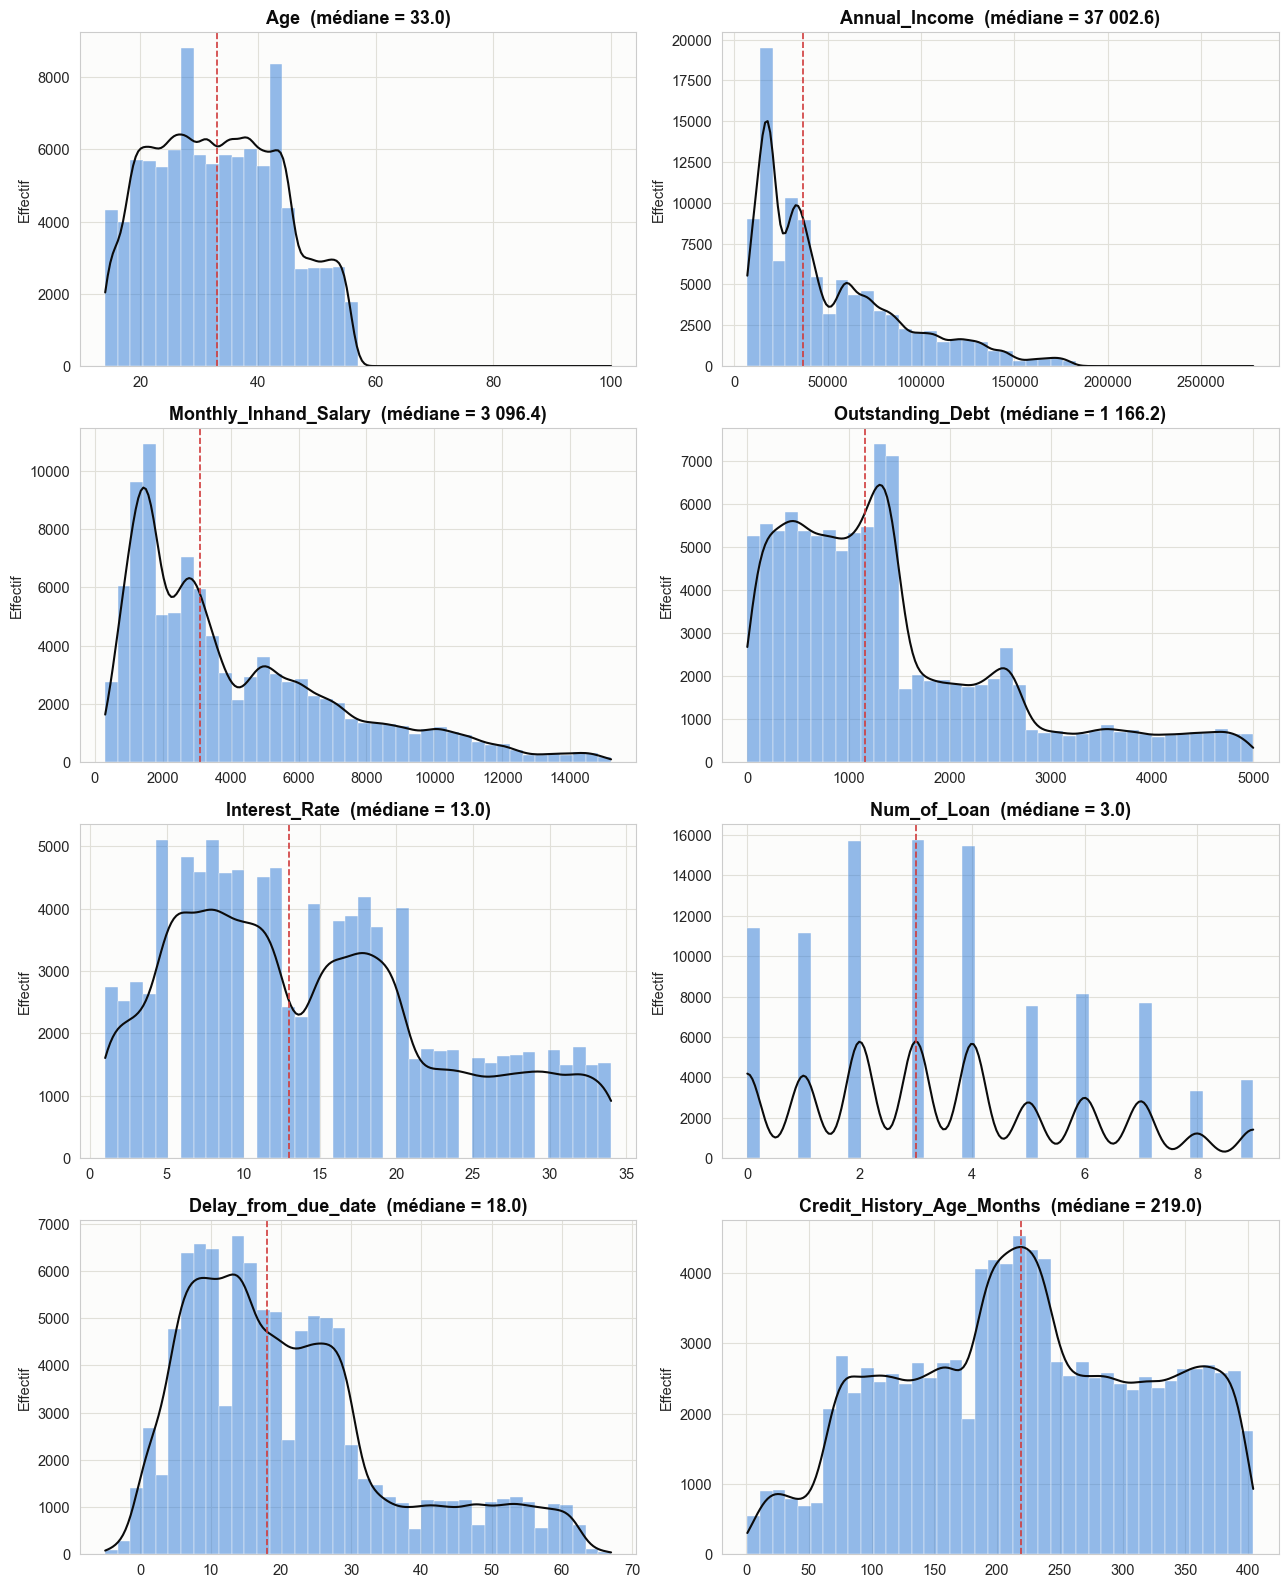

In [10]:
UNIVARIATE_NUM_COLS = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Credit_History_Age_Months',
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for ax, col in zip(axes, UNIVARIATE_NUM_COLS):
    sns.histplot(df[col].dropna(), bins=40, color=SEQUENTIAL_BLUE, edgecolor=SURFACE,
                 linewidth=0.3, kde=True, ax=ax)
    ax.lines[0].set_color(PRIMARY_INK)
    ax.lines[0].set_linewidth(1.5)
    mediane = df[col].median()
    ax.axvline(mediane, color=STATUS_COLORS['Poor'], linestyle='--', linewidth=1.2)
    ax.set_title(f"{col}  (médiane = {mediane:,.1f})".replace(',', ' '))
    ax.set_xlabel('')
    ax.set_ylabel('Effectif')

plt.tight_layout()
plt.show()


**Lecture rapide :** `Annual_Income`, `Outstanding_Debt` et `Delay_from_due_date`
présentent des distributions étalées à droite (quelques clients avec des valeurs
très élevées), tandis que `Age` et `Interest_Rate` sont plus proches d'une
distribution centrée. `Credit_History_Age_Months` couvre un large historique de
crédit, de quelques mois à plus de 30 ans.


## 4. Analyse bivariée : variables numériques vs `Credit_Score`

Pour chaque variable numérique, un boxplot par classe de `Credit_Score` permet de
comparer les distributions selon la cible. Les trois classes gardent la même
couleur de statut dans tout le notebook (`Good` = vert, `Standard` = orange,
`Poor` = rouge) pour rester immédiatement reconnaissables.


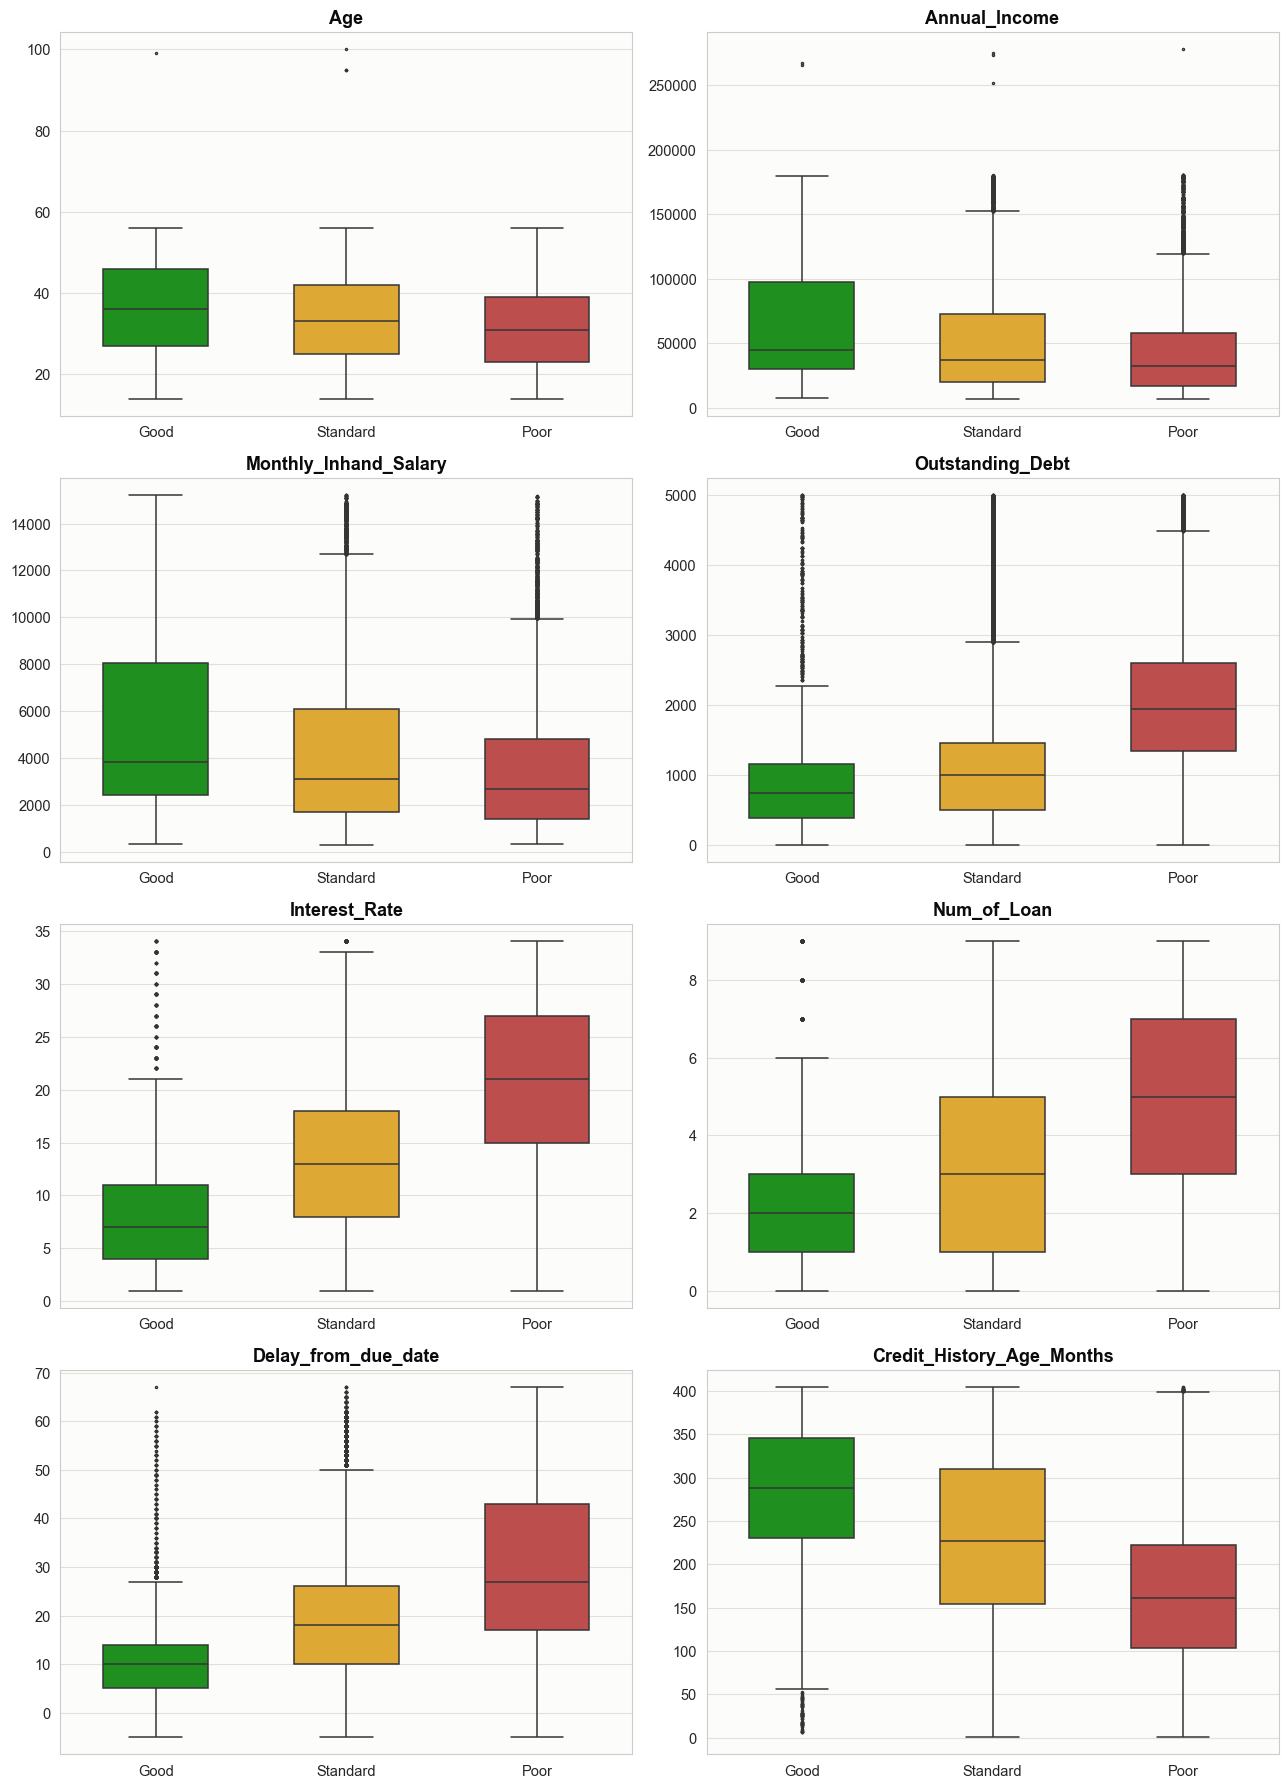

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()

for ax, col in zip(axes, UNIVARIATE_NUM_COLS):
    sns.boxplot(
        data=df, x='Credit_Score', y=col, order=CREDIT_SCORE_ORDER,
        hue='Credit_Score', palette=STATUS_COLORS, legend=False,
        width=0.55, fliersize=1.5, linewidth=1.1, ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


**Lecture rapide :** les clients `Poor` se distinguent par un `Outstanding_Debt`
et un `Interest_Rate` médians plus élevés, ainsi qu'un `Delay_from_due_date` plus
important. À l'inverse, les clients `Good` ont un `Credit_History_Age_Months` plus
élevé (historique de crédit plus long) et un `Annual_Income` généralement plus
haut. Ces variables apparaissent donc comme de bons signaux discriminants pour la
modélisation.


## 5. Analyse des variables catégorielles vs `Credit_Score`

Pour chaque variable catégorielle, on calcule la répartition du `Credit_Score`
**au sein de chaque catégorie** (pourcentages en ligne), puis on l'affiche en
barres empilées à 100 %, triées par part de `Poor` décroissante — la lecture la
plus utile pour repérer les catégories à risque. Les couleurs restent celles de
la cible (statut fixe), la forme "barres empilées horizontales" étant la plus
adaptée aux catégories nombreuses ou aux libellés longs.


In [12]:
def plot_categorielle_vs_cible(colonne, ax=None, top_n=None):
    """Barres empilées à 100% de Credit_Score au sein de chaque catégorie de `colonne`,
    triées par part de 'Poor' décroissante."""
    ct = pd.crosstab(df[colonne], df['Credit_Score'], normalize='index')[CREDIT_SCORE_ORDER] * 100
    ct = ct.sort_values('Poor', ascending=True)
    if top_n is not None:
        ct = ct.tail(top_n)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(ct))))

    left = np.zeros(len(ct))
    for classe in CREDIT_SCORE_ORDER:
        ax.barh(ct.index, ct[classe], left=left, color=STATUS_COLORS[classe],
                label=classe, height=0.65)
        left += ct[classe].values

    ax.set_xlim(0, 100)
    ax.set_xlabel('Part des relevés (%)')
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    return ax


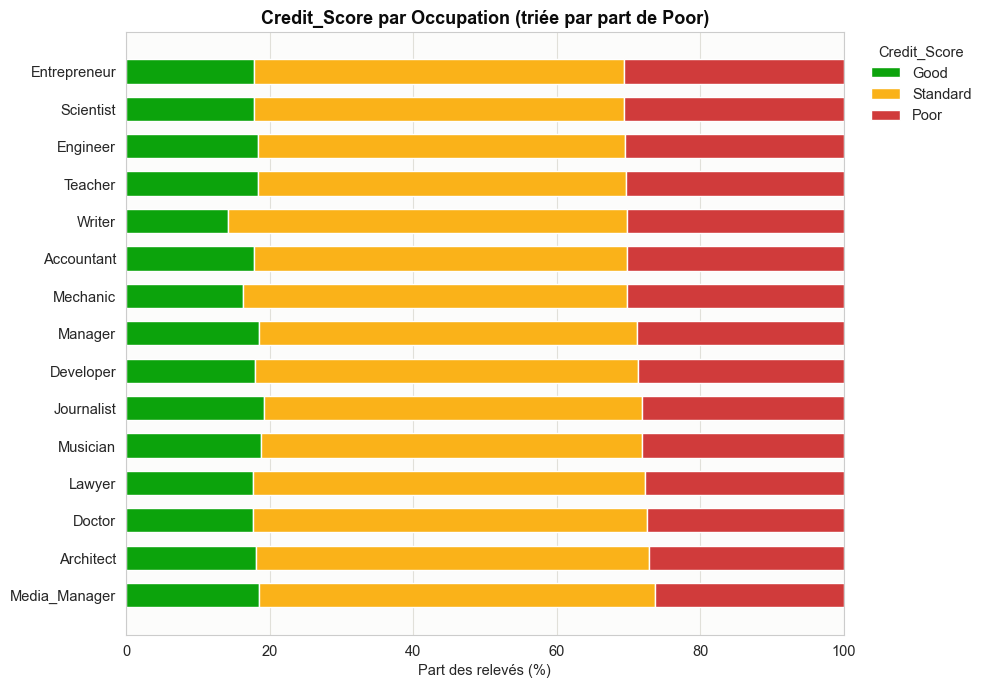

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_categorielle_vs_cible('Occupation', ax=ax)
ax.set_title("Credit_Score par Occupation (triée par part de Poor)")
ax.legend(title='Credit_Score', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


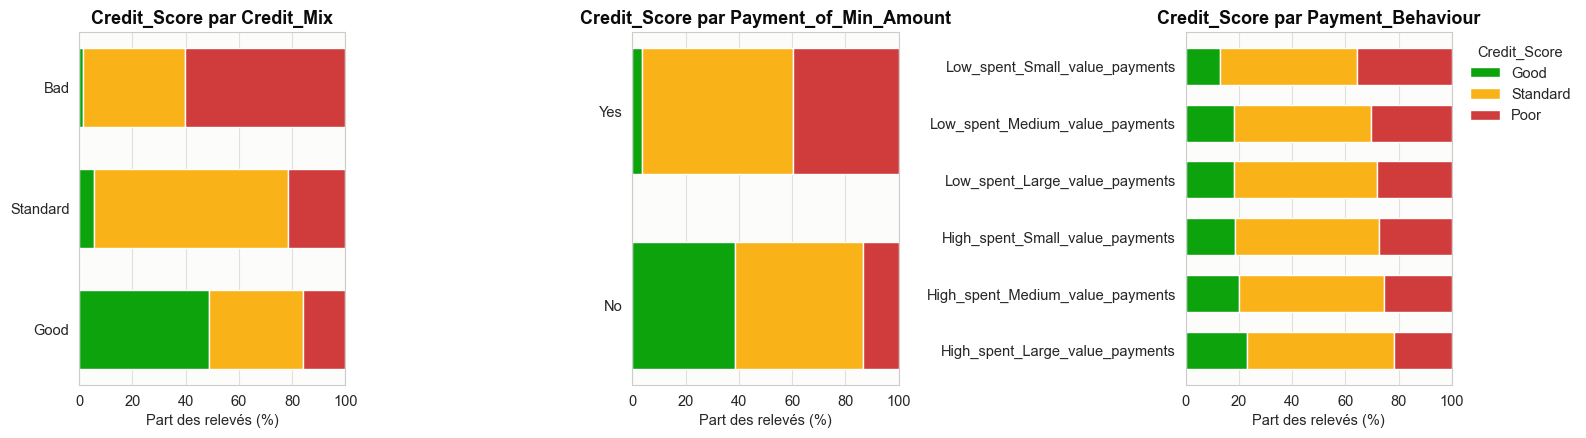

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_categorielle_vs_cible('Credit_Mix', ax=axes[0])
axes[0].set_title("Credit_Score par Credit_Mix")

plot_categorielle_vs_cible('Payment_of_Min_Amount', ax=axes[1])
axes[1].set_title("Credit_Score par Payment_of_Min_Amount")

plot_categorielle_vs_cible('Payment_Behaviour', ax=axes[2])
axes[2].set_title("Credit_Score par Payment_Behaviour")
axes[2].legend(title='Credit_Score', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


**Lecture rapide :** `Credit_Mix = Bad` concentre une part de `Poor` nettement plus
élevée que `Good`/`Standard`, ce qui en fait une variable très discriminante.
`Payment_of_Min_Amount = Yes` (le client se contente de payer le montant minimum
dû, sans jamais rembourser plus) est également associé à une part de `Poor`
beaucoup plus forte ; à l'inverse, `Payment_of_Min_Amount = No` concentre la
majorité des clients `Good`. Du côté de `Occupation`, les écarts entre professions
sont plus modestes, suggérant un pouvoir prédictif individuel plus faible pour
cette variable.


## 6. Matrice de corrélation des variables numériques

La corrélation est une mesure de **polarité** (positive, négative, ou nulle) : on
utilise donc une palette divergente bleu (négatif) → gris (nul) → rouge (positif),
et non une palette séquentielle à une seule teinte.


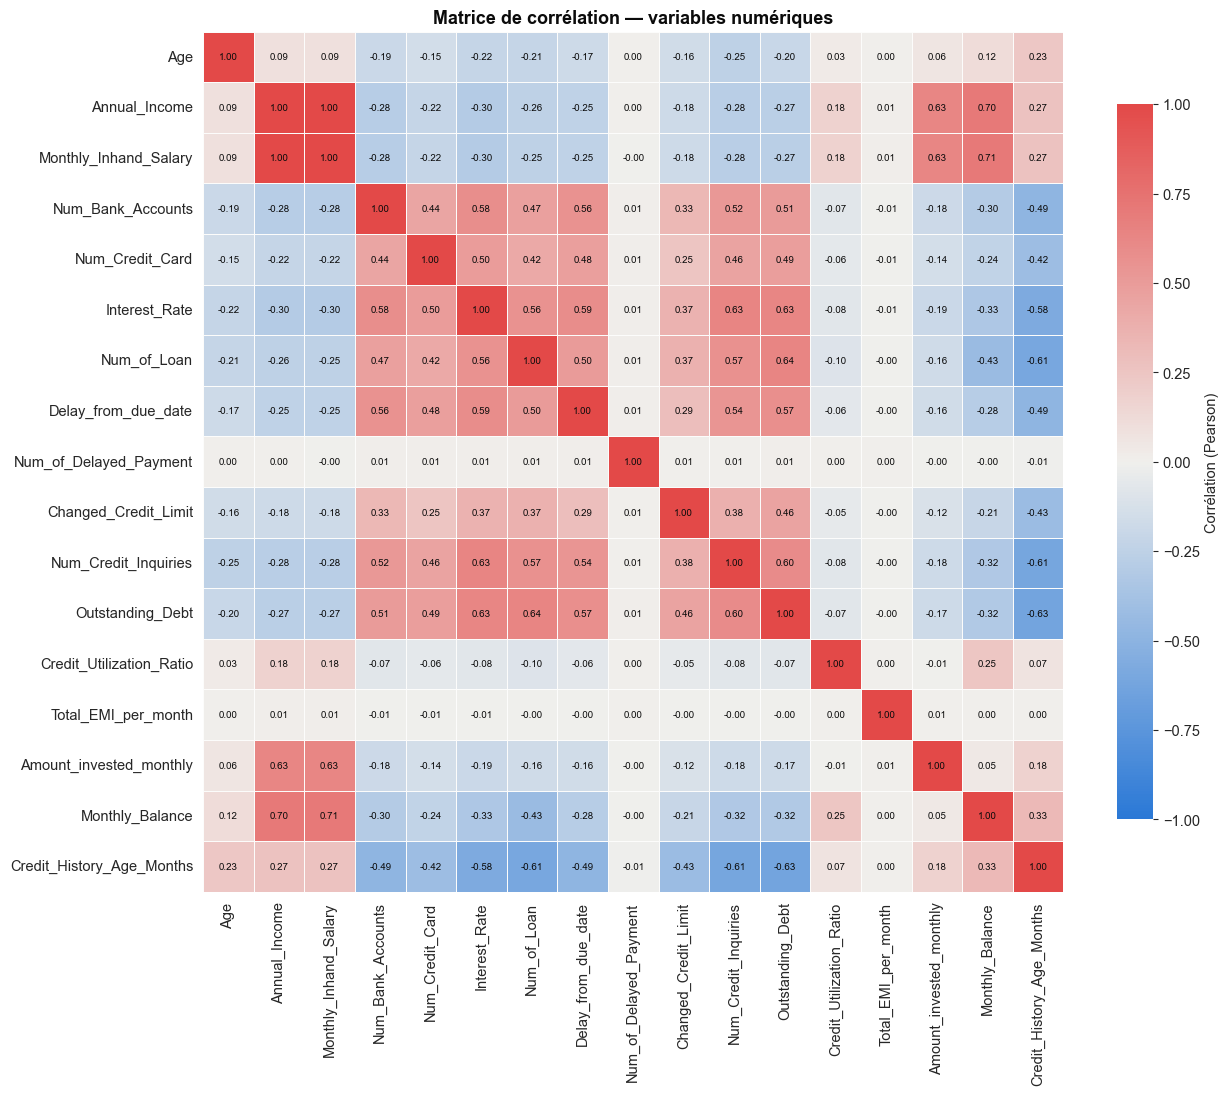

In [15]:
CORR_COLS = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months',
]

corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7, 'color': PRIMARY_INK},
    linewidths=0.6, linecolor=SURFACE, square=True,
    cbar_kws={'label': 'Corrélation (Pearson)', 'shrink': 0.8}, ax=ax,
)
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()


In [16]:
# Paires les plus corrélées (hors diagonale), en valeur absolue
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename('correlation')
    .reset_index()
    .rename(columns={'level_0': 'variable_1', 'level_1': 'variable_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
top_corr = corr_pairs.sort_values('abs_correlation', ascending=False).head(10)
top_corr[['variable_1', 'variable_2', 'correlation']]


,variable_1,variable_2,correlation
19,Annual_Income,Monthly_Inhand_Salary,0.997105
49,Monthly_Inhand_Salary,Monthly_Balance,0.706741
32,Annual_Income,Monthly_Balance,0.704872
113,Num_of_Loan,Outstanding_Debt,0.638713
95,Interest_Rate,Num_Credit_Inquiries,0.633376
96,Interest_Rate,Outstanding_Debt,0.629414
203,Outstanding_Debt,Credit_History_Age_Months,-0.629312
48,Monthly_Inhand_Salary,Amount_invested_monthly,0.628107
31,Annual_Income,Amount_invested_monthly,0.626686
186,Num_Credit_Inquiries,Credit_History_Age_Months,-0.610472


**Lecture rapide :** `Annual_Income` et `Monthly_Inhand_Salary` sont quasiment
colinéaires (r ≈ 0.997, ce qui est cohérent puisque le second dérive du premier)
— un seul des deux suffit pour un modèle linéaire, ou il faut appliquer une
régularisation si les deux sont conservées. En dehors de cette paire, les
corrélations restent modérées : `Num_of_Loan`, `Interest_Rate` et
`Num_Credit_Inquiries` sont corrélées positivement à `Outstanding_Debt`, tandis
que `Outstanding_Debt` et `Num_Credit_Inquiries` sont corrélées négativement à
`Credit_History_Age_Months` (les clients au dossier de crédit plus ancien ont
tendance à moins solliciter de nouveaux crédits et à moins s'endetter).


## 7. Analyse spécifique : élasticité des revenus par client

Chaque client (`Customer_ID`) est suivi sur plusieurs mois. On mesure ici la
**variabilité intra-client** de `Monthly_Balance` et `Monthly_Inhand_Salary` via
le **coefficient de variation** (CV = écart-type / moyenne) calculé par client.
Un CV élevé indique un revenu ou un solde mensuel instable d'un mois à l'autre —
un signal potentiellement lié au risque de crédit.


In [17]:
def coefficient_variation_par_client(colonne):
    stats_client = df.groupby('Customer_ID')[colonne].agg(['mean', 'std', 'count'])
    stats_client = stats_client[(stats_client['count'] >= 2) & (stats_client['mean'] > 0)]
    stats_client['cv'] = stats_client['std'] / stats_client['mean']
    return stats_client

cv_balance = coefficient_variation_par_client('Monthly_Balance')
cv_salaire = coefficient_variation_par_client('Monthly_Inhand_Salary')

print(f"Clients analysés (Monthly_Balance)        : {len(cv_balance)}")
print(f"Clients analysés (Monthly_Inhand_Salary)   : {len(cv_salaire)}")

pd.DataFrame({
    'CV Monthly_Balance': cv_balance['cv'].describe(),
    'CV Monthly_Inhand_Salary': cv_salaire['cv'].describe(),
})


Clients analysés (Monthly_Balance)        : 12500
Clients analysés (Monthly_Inhand_Salary)   : 12500


,CV Monthly_Balance,CV Monthly_Inhand_Salary
count,12500.000000,12500.000000
mean,0.236102,0.002169
std,0.138441,0.009717
min,0.016191,0.000000
25%,0.127512,0.000000
50%,0.206493,0.000000
75%,0.322515,0.000000
max,1.057738,0.107582


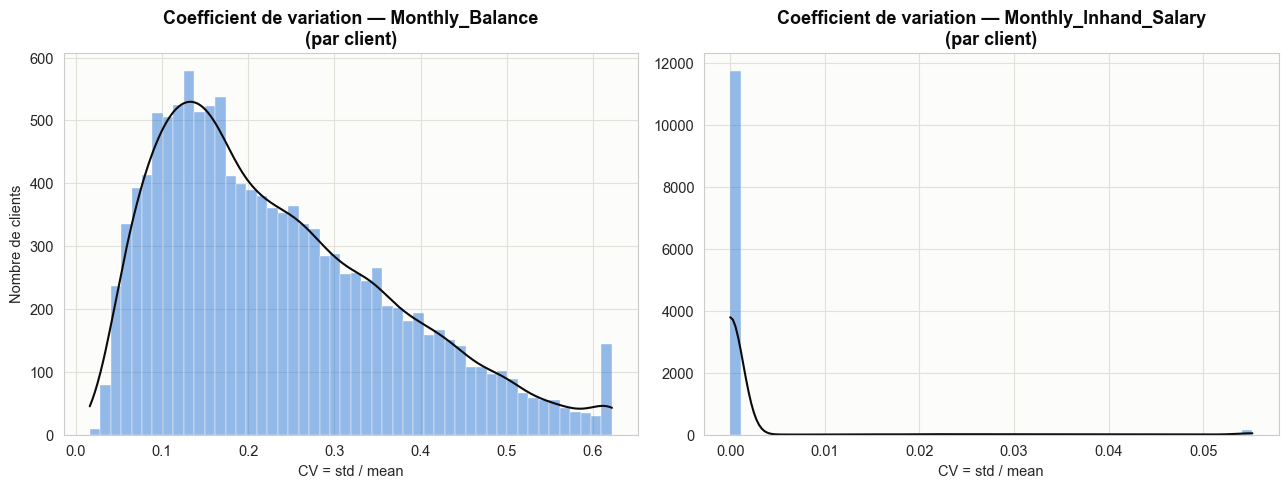

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(cv_balance['cv'].clip(upper=cv_balance['cv'].quantile(0.99)), bins=50,
             color=SEQUENTIAL_BLUE, edgecolor=SURFACE, linewidth=0.3, kde=True, ax=axes[0])
axes[0].lines[0].set_color(PRIMARY_INK)
axes[0].set_title("Coefficient de variation — Monthly_Balance\n(par client)")
axes[0].set_xlabel('CV = std / mean')
axes[0].set_ylabel('Nombre de clients')

sns.histplot(cv_salaire['cv'].clip(upper=cv_salaire['cv'].quantile(0.99)), bins=50,
             color=SEQUENTIAL_BLUE, edgecolor=SURFACE, linewidth=0.3, kde=True, ax=axes[1])
axes[1].lines[0].set_color(PRIMARY_INK)
axes[1].set_title("Coefficient de variation — Monthly_Inhand_Salary\n(par client)")
axes[1].set_xlabel('CV = std / mean')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [19]:
# Le CV de Monthly_Balance et Monthly_Inhand_Salary est-il lié au Credit_Score ?
cv_vs_cible = df[['Customer_ID', 'Credit_Score']].drop_duplicates('Customer_ID')
cv_vs_cible = cv_vs_cible.merge(cv_balance['cv'].rename('cv_balance'), on='Customer_ID', how='inner')
cv_vs_cible = cv_vs_cible.merge(cv_salaire['cv'].rename('cv_salaire'), on='Customer_ID', how='inner')

resume_cv = cv_vs_cible.groupby('Credit_Score')[['cv_balance', 'cv_salaire']].median().reindex(CREDIT_SCORE_ORDER)
resume_cv.columns = ['CV médian Monthly_Balance', 'CV médian Monthly_Inhand_Salary']
resume_cv


,CV médian Monthly_Balance,CV médian Monthly_Inhand_Salary
Credit_Score,,
Good,0.237311,0.0
Standard,0.208560,0.0
Poor,0.181300,0.0


**Lecture rapide :** `Monthly_Inhand_Salary` est quasiment invariant d'un mois à
l'autre pour un même client (CV très proche de 0 pour la quasi-totalité des
clients) — le salaire déclaré est une caractéristique stable, cohérent avec un
revenu fixe. `Monthly_Balance` montre au contraire une réelle variabilité intra-
client (CV généralement entre 0.1 et 0.4, parfois davantage), un indicateur
d'instabilité financière plus riche que le salaire brut. Le tableau ci-dessous
compare le CV médian par classe de `Credit_Score`, pour vérifier si cette
variabilité de solde est associée à la qualité de crédit du client.


## 8. Synthèse des insights clés pour la modélisation


In [20]:
poor_share = target_pct['Poor']
good_share = target_pct['Good']
standard_share = target_pct['Standard']

moyennes_par_classe = df.groupby('Credit_Score')[
    ['Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date',
     'Credit_History_Age_Months', 'Annual_Income']
].mean().reindex(CREDIT_SCORE_ORDER)

credit_mix_bad_poor_share = pd.crosstab(
    df['Credit_Mix'], df['Credit_Score'], normalize='index'
).loc['Bad', 'Poor'] * 100

min_amount_yes_poor_share = pd.crosstab(
    df['Payment_of_Min_Amount'], df['Credit_Score'], normalize='index'
).loc['Yes', 'Poor'] * 100

print("=== Insights clés ===\n")
print(f"1. Cible déséquilibrée : Standard {standard_share:.1f} % / Poor {poor_share:.1f} % "
      f"/ Good {good_share:.1f} % -> prévoir une pondération des classes ou un "
      f"suréchantillonnage, et privilégier des métriques comme le F1 macro.\n")

print("2. Variables numériques discriminantes (moyenne par classe) :")
print(moyennes_par_classe.round(1).to_string())
print()

print(f"3. Credit_Mix = 'Bad' -> {credit_mix_bad_poor_share:.1f} % des relevés sont 'Poor' : "
      f"variable catégorielle la plus discriminante identifiée.\n")

print(f"4. Payment_of_Min_Amount = 'Yes' -> {min_amount_yes_poor_share:.1f} % des relevés sont "
      f"'Poor' : deuxième variable catégorielle la plus discriminante.\n")

print(f"5. Annual_Income et Monthly_Inhand_Salary sont quasi colinéaires "
      f"(r = {corr.loc['Annual_Income', 'Monthly_Inhand_Salary']:.3f}) : n'en garder qu'une "
      f"seule (ou régulariser) pour un modèle linéaire ; les autres paires restent modérément "
      f"corrélées, sans colinéarité problématique.\n")

print(f"6. Le salaire mensuel (Monthly_Inhand_Salary) est quasi constant d'un mois à l'autre pour "
      f"un même client (CV médian = {resume_cv.loc['Standard', 'CV médian Monthly_Inhand_Salary']:.3f}), "
      f"alors que le solde mensuel (Monthly_Balance) varie nettement plus (CV médian entre "
      f"{resume_cv['CV médian Monthly_Balance'].min():.2f} et {resume_cv['CV médian Monthly_Balance'].max():.2f} "
      f"selon la classe) : cette variabilité de solde est une feature dérivée par client "
      f"potentiellement utile, plus informative que le salaire brut.")


=== Insights clés ===

1. Cible déséquilibrée : Standard 53.2 % / Poor 29.0 % / Good 17.8 % -> prévoir une pondération des classes ou un suréchantillonnage, et privilégier des métriques comme le F1 macro.

2. Variables numériques discriminantes (moyenne par classe) :
              Outstanding_Debt  Interest_Rate  Delay_from_due_date  Credit_History_Age_Months  Annual_Income
Credit_Score                                                                                                
Good                     801.3            7.7                 10.9                      284.7        65229.0
Standard                1278.4           13.8                 19.7                      227.7        50999.4
Poor                    2081.5           20.2                 29.7                      170.0        40593.8

3. Credit_Mix = 'Bad' -> 60.1 % des relevés sont 'Poor' : variable catégorielle la plus discriminante identifiée.

4. Payment_of_Min_Amount = 'Yes' -> 39.6 % des relevés sont 'Poor' : de

### À retenir pour la suite du projet

- **Déséquilibre de classes** : `Standard` domine, `Good` est minoritaire — à
  gérer explicitement lors de l'entraînement (poids de classe, rééchantillonnage)
  et de l'évaluation (F1 macro, matrice de confusion plutôt que la seule accuracy).
- **Signaux numériques forts** : `Outstanding_Debt`, `Interest_Rate`,
  `Delay_from_due_date` et `Credit_History_Age_Months` séparent clairement les
  classes dans les boxplots — bons candidats pour un modèle simple et pour
  l'interprétation métier.
- **Signaux catégoriels forts** : `Credit_Mix` (`Bad` -> forte part de `Poor`) et
  `Payment_of_Min_Amount` (`Yes` -> forte part de `Poor`) sont les variables
  catégorielles les plus discriminantes ; `Occupation` l'est beaucoup moins et
  pourrait être regroupée ou déprioritisée.
- **Colinéarité à traiter** : `Annual_Income` et `Monthly_Inhand_Salary` sont
  quasi colinéaires (r ≈ 0.997) — n'en conserver qu'une seule, ou régulariser,
  pour un modèle linéaire ; les autres paires de variables restent modérément
  corrélées, sans colinéarité problématique.
- **Variabilité intra-client (CV)** : `Monthly_Balance` varie sensiblement d'un
  mois à l'autre pour un même client, contrairement à `Monthly_Inhand_Salary`
  qui reste quasi constant — le CV du solde par client est donc une feature
  dérivée plus informative que le salaire brut à ajouter au feature engineering,
  même si son lien direct avec `Credit_Score` reste à confirmer par une analyse
  multivariée plus poussée.
